## Import Libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Load the dataset:

In [8]:
df = pd.read_csv('AirPassengers.csv')
print(df.head())

     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121


## Look at the dataset:

In [9]:
print(df.tail())

       Month  #Passengers
139  1960-08          606
140  1960-09          508
141  1960-10          461
142  1960-11          390
143  1960-12          432


In [10]:
print(df.shape)

(144, 2)


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None


## Statistical Analysis:

In [12]:
print(df.describe())

       #Passengers
count   144.000000
mean    280.298611
std     119.966317
min     104.000000
25%     180.000000
50%     265.500000
75%     360.500000
max     622.000000


## Null Values:

In [13]:
print(df.isnull().sum())

Month          0
#Passengers    0
dtype: int64


## Conversion of date into datetime:

In [17]:
df["Month"] = pd.to_datetime(df["Month"])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   #Passengers  144 non-null    int64         
 1   Date         144 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 3.4 KB


In [ ]:
df = df.set_index("Month").rename_axis("Date")

In [24]:
df.head()

,#Passengers
Date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [25]:
df.loc["1950"]

,#Passengers
Date,
1950-01-01,115
1950-02-01,126
1950-03-01,141
1950-04-01,135
1950-05-01,125
1950-06-01,149
1950-07-01,170
1950-08-01,170
1950-09-01,158


In [26]:
df.loc["1950":"1952"]

,#Passengers
Date,
1950-01-01,115
1950-02-01,126
1950-03-01,141
1950-04-01,135
1950-05-01,125
1950-06-01,149
1950-07-01,170
1950-08-01,170
1950-09-01,158


## Check the time range:

In [27]:
print("Start date:",df.index.min())
print("End date:",df.index.max())

Start date: 1949-01-01 00:00:00
End date: 1960-12-01 00:00:00


In [ ]:
print("Number of observations:", len(df))# rows are observations

Number of observations: 144


## check whether dates are monthly:

In [29]:
print(df.index.freq)

None


In [30]:
df = df.asfreq("MS")

## First visualization:

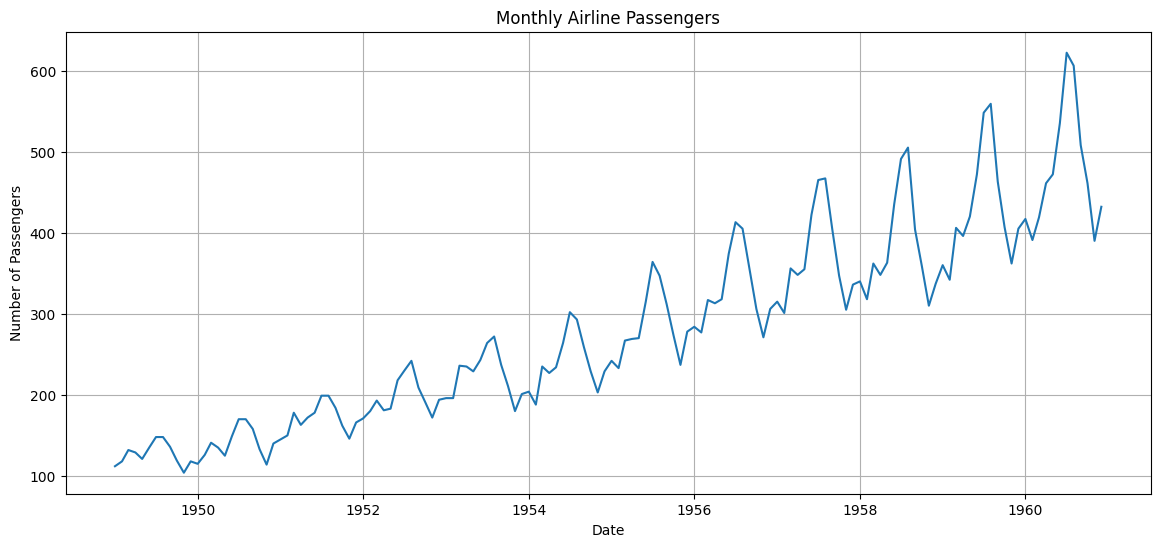

In [32]:
plt.figure(figsize=(14,6))
plt.plot(df.index,df["#Passengers"])
plt.title("Monthly Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Number of Passengers")

plt.grid()
plt.show()

## Interactive Plotly version:

In [36]:
fig = px.line(
    df,
    x=df.index,
    y="#Passengers",
    title="Monthly Airline Passengers"
)
fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Number of Passengers",
    hovermode="x unified"
)

fig.show()

## with better labels:

In [40]:
plot_df = df.reset_index()

fig = px.line(
    plot_df,
    x="Date",
    y="#Passengers",
    title="Airline Passenger Trend"
)

#fig.update_traces(
    #line_width=2
#)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Passengers",
    hovermode="x unified"
)

fig.show()

## Look at yearly passenger totals:

In [43]:
yearly_passengers = df.resample("Y").sum()
yearly_passengers.head()

C:\Users\RGB LAPTOPS\AppData\Local\Temp\ipykernel_12304\1723117272.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_passengers = df.resample("Y").sum()


,#Passengers
Date,
1949-12-31,1520
1950-12-31,1676
1951-12-31,2042
1952-12-31,2364
1953-12-31,2700


# Plots:

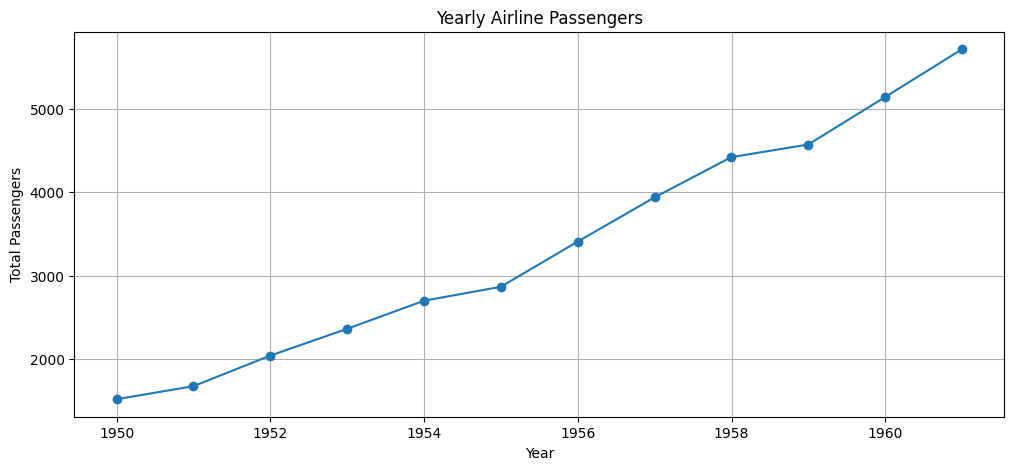

In [46]:
plt.figure(figsize=(12, 5))

plt.plot(
    yearly_passengers.index,
    yearly_passengers.values,
    marker="o"
)

plt.title("Yearly Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Total Passengers")

plt.grid()
plt.show()

## Plotly:

In [47]:
yearly_df = yearly_passengers.reset_index()

fig = px.line(
    yearly_df,
    x="Date",
    y="#Passengers",
    markers=True,
    title="Yearly Airline Passengers"
)

fig.show()

## Monthly seasonality:

In [48]:
df["Month"] = df.index.month

In [49]:
monthly_avg = df.groupby("Month")["#Passengers"].mean()
print(monthly_avg)

Month
1     241.750000
2     235.000000
3     270.166667
4     267.083333
5     271.833333
6     311.666667
7     351.333333
8     351.083333
9     302.416667
10    266.583333
11    232.833333
12    261.833333
Name: #Passengers, dtype: float64


## Plot:

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.title("Average Passengers by Month")
plt.xlabel("Month")
plt.ylabel("Average Passengers")

plt.xticks(range(1, 13))
plt.grid()

plt.show()

## Plotly monthly seasonality:

In [51]:
monthly_df = monthly_avg.reset_index()

fig = px.line(
    monthly_df,
    x="Month",
    y="#Passengers",
    markers=True,
    title="Average Airline Passengers by Month"
)

fig.update_layout(
    xaxis=dict(
        tickmode="linear",
        dtick=1
    )
)

fig.show()

## Moving Average:

>moving average smooths the data:

In [52]:
df["12 Month MA"] = df["#Passengers"].rolling(window=12).mean()

## Plot:

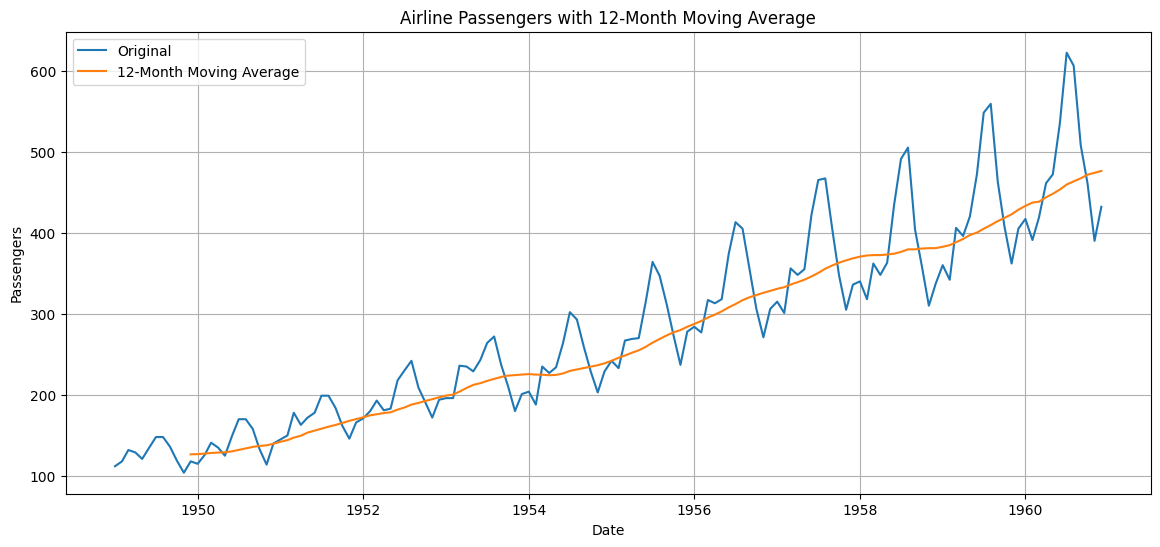

In [ ]:
df = df.set_index("Month").rename_axis("Date")

In [56]:
ma_df = df.reset_index()
from plotly import graph_objects as go
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=ma_df["Date"],
        y=ma_df["#Passengers"],
        mode="lines",
        name="Original"
    )
)

fig.add_trace(
    go.Scatter(
        x=ma_df["Date"],
        y=ma_df["12 Month MA"],
        mode="lines",
        name="12-Month Moving Average"
    )
)

fig.update_layout(
    title="Airline Passengers — Original vs Moving Average",
    xaxis_title="Date",
    yaxis_title="Passengers",
    hovermode="x unified"
)

fig.show()

## Time-Series Decomposition:

In [57]:
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose 
seasonal_decomposition = sm.tsa.seasonal_decompose(df["#Passengers"],model="multiplicative",period=12)

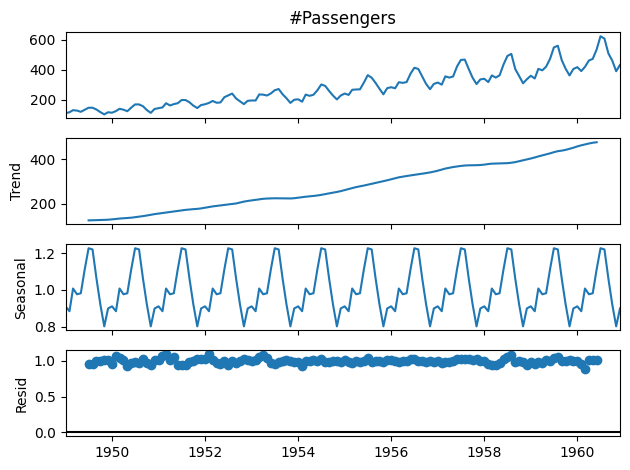

In [59]:
decomposition = seasonal_decompose(
    df["#Passengers"],
    model = "multiplicative",
    period = 12#Look for a repeating pattern every 12 observations.
)
decomposition.plot()
plt.show()

# Plot each decomposition:

### Trend:

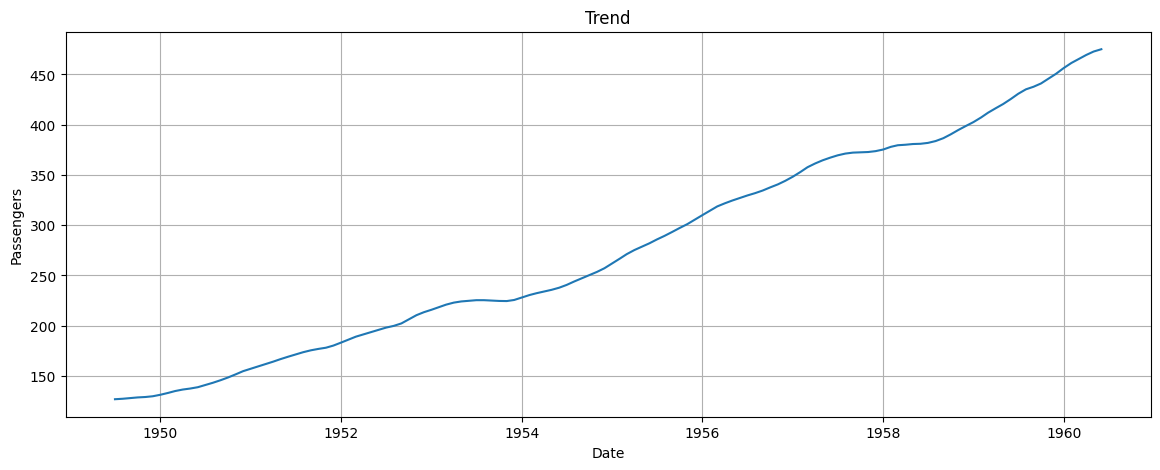

In [60]:
plt.figure(figsize=(14, 5))

plt.plot(decomposition.trend)

plt.title("Trend")
plt.xlabel("Date")
plt.ylabel("Passengers")

plt.grid()
plt.show()

### Seasonal:

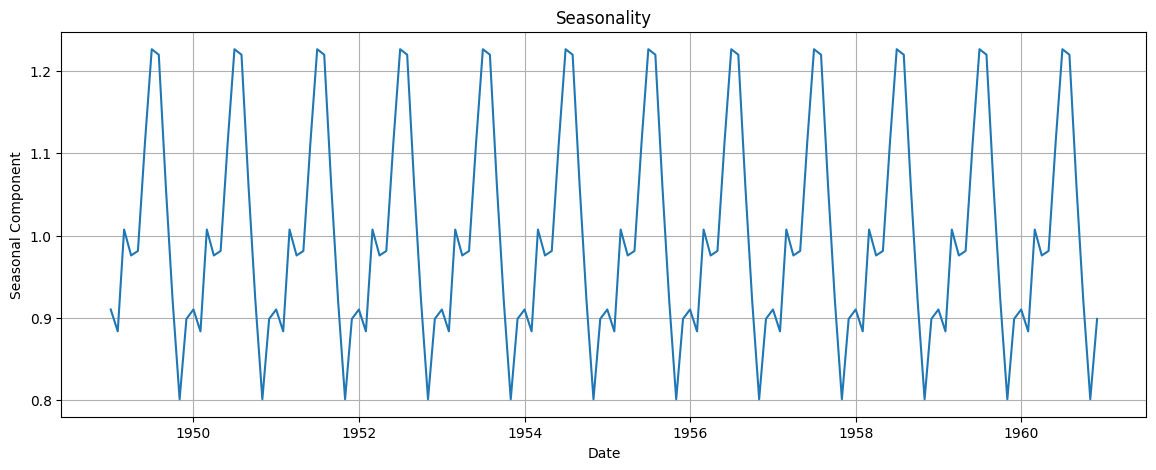

In [61]:
plt.figure(figsize=(14, 5))

plt.plot(decomposition.seasonal)

plt.title("Seasonality")
plt.xlabel("Date")
plt.ylabel("Seasonal Component")

plt.grid()
plt.show()

## Residual:

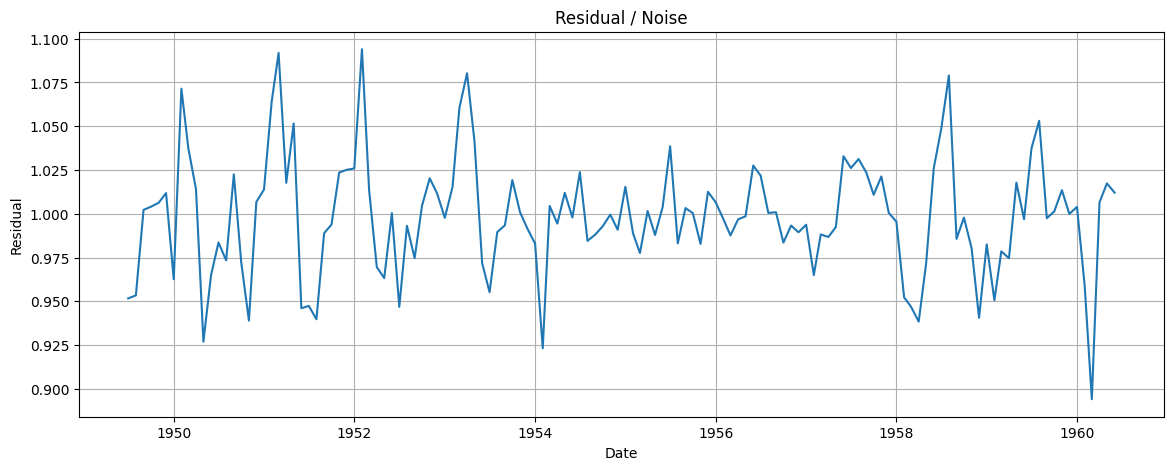

In [62]:
plt.figure(figsize=(14, 5))

plt.plot(decomposition.resid)

plt.title("Residual / Noise")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.grid()
plt.show()

# Interactive decomposition with Plotly:

In [63]:
decomp_df = pd.DataFrame({
    "Date": df.index,
    "Observed": decomposition.observed,
    "Trend": decomposition.trend,
    "Seasonal": decomposition.seasonal,
    "Residual": decomposition.resid
})

In [64]:
fig = px.line(
    decomp_df,
    x="Date",
    y=[
        "Observed",
        "Trend",
        "Seasonal",
        "Residual"
    ],
    title="Time Series Decomposition"
)

fig.show()

## Stationarity:

>airline passenger data clearly has:
>↗ increasing trend & seasonality
>So it is not stationary.
>>We can test it using the ADF test.

# Augmented Dickey-Fuller test:

In [65]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["#Passengers"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641


In [66]:
if result[1] <= 0.05:
    print("The series is likely stationary.")
else:
    print("The series is likely non-stationary.")

The series is likely non-stationary.


## Train/Test Split:

In [68]:
train_size = int(len(df)*0.8)
train = df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()
print("Train_size:",len(train))
print("Test_size:",len(test))

Train_size: 115
Test_size: 29


## Visualize the split:

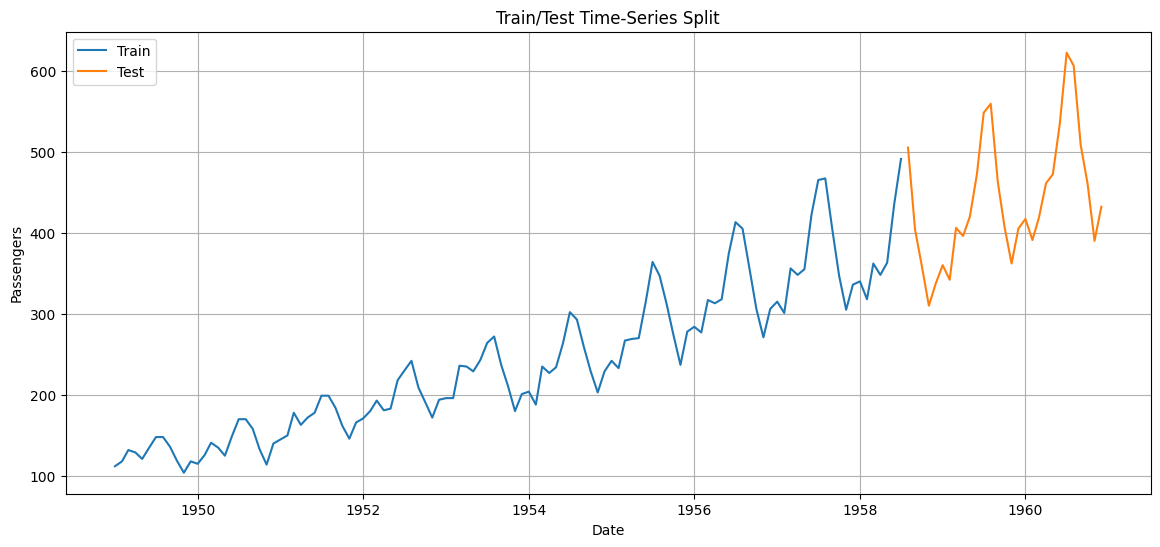

In [69]:
plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train["#Passengers"],
    label="Train"
)

plt.plot(
    test.index,
    test["#Passengers"],
    label="Test"
)

plt.title("Train/Test Time-Series Split")
plt.xlabel("Date")
plt.ylabel("Passengers")

plt.legend()
plt.grid()

plt.show()

## Create Lag Features:

In [70]:
df["lag_1"] = df["#Passengers"].shift(1)

>Previous month's passengers.

#### Multiple lags:

In [72]:
df["lag_1"] = df["#Passengers"].shift(1)
df["lag_2"] = df["#Passengers"].shift(2)
df["lag_3"] = df["#Passengers"].shift(3)

df.head()

,#Passengers,Month,12 Month MA,lag_1,lag_2,lag_3
Date,,,,,,
1949-01-01,112,1,NaN,NaN,NaN,NaN
1949-02-01,118,2,NaN,112.0,NaN,NaN
1949-03-01,132,3,NaN,118.0,112.0,NaN
1949-04-01,129,4,NaN,132.0,118.0,112.0
1949-05-01,121,5,NaN,129.0,132.0,118.0


In [74]:
df["lag_12"] = df["#Passengers"].shift(12)

>Passenger value from exactly one year ago.

## Let's create a clean modeling dataset

In [75]:
model_df = df[
    [
        "#Passengers",
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_12"
    ]
].dropna()

In [76]:
model_df.head()

,#Passengers,lag_1,lag_2,lag_3,lag_12
Date,,,,,
1950-01-01,115,118.0,104.0,119.0,112.0
1950-02-01,126,115.0,118.0,104.0,118.0
1950-03-01,141,126.0,115.0,118.0,132.0
1950-04-01,135,141.0,126.0,115.0,129.0
1950-05-01,125,135.0,141.0,126.0,121.0


# Prepare X & Y:

In [77]:
X = model_df[
    [
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_12"
    ]
]

y = model_df["#Passengers"]

>Use previous passenger values to predict the current passenger value.

## Time-based split again

In [78]:
train_size = int(len(model_df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

## First forecasting model — Linear Regression:

In [79]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Prediction:

In [80]:
y_pred = model.predict(X_test)

Evaluate

In [86]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

MAE:

In [82]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 15.082780887275744


RMSE:

In [83]:
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("RMSE:", rmse)

print("MAE:", mae)

RMSE: 18.009571524172664
MAE: 15.082780887275744


***************************

# Actual vs Predicted

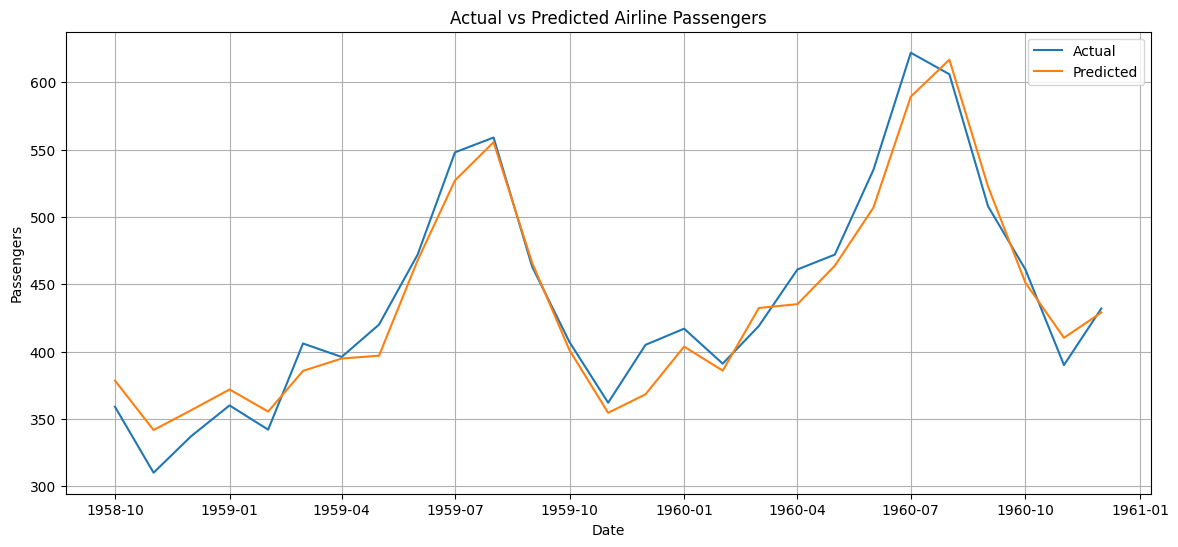

In [87]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual"
)

plt.plot(
    y_test.index,
    y_pred,
    label="Predicted"
)

plt.title("Actual vs Predicted Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")

plt.legend()
plt.grid()

plt.show()

## Plotly:

In [88]:
prediction_df = pd.DataFrame({
    "Date": y_test.index,
    "Actual": y_test.values,
    "Predicted": y_pred
})

In [89]:
fig = px.line(
    prediction_df,
    x="Date",
    y=["Actual", "Predicted"],
    title="Actual vs Predicted Airline Passengers"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Passengers",
    hovermode="x unified"
)

fig.show()